In [4]:
cols = ["duration","protocol_type","service","flag","src_bytes","dst_bytes",
        "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
        "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
        "num_shells","num_access_files","num_outbound_cmds","is_host_login",
        "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
        "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
        "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
        "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
        "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
        "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

df.columns = cols

print(df.shape)
df.head()

(125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
print(df["label"].value_counts())

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


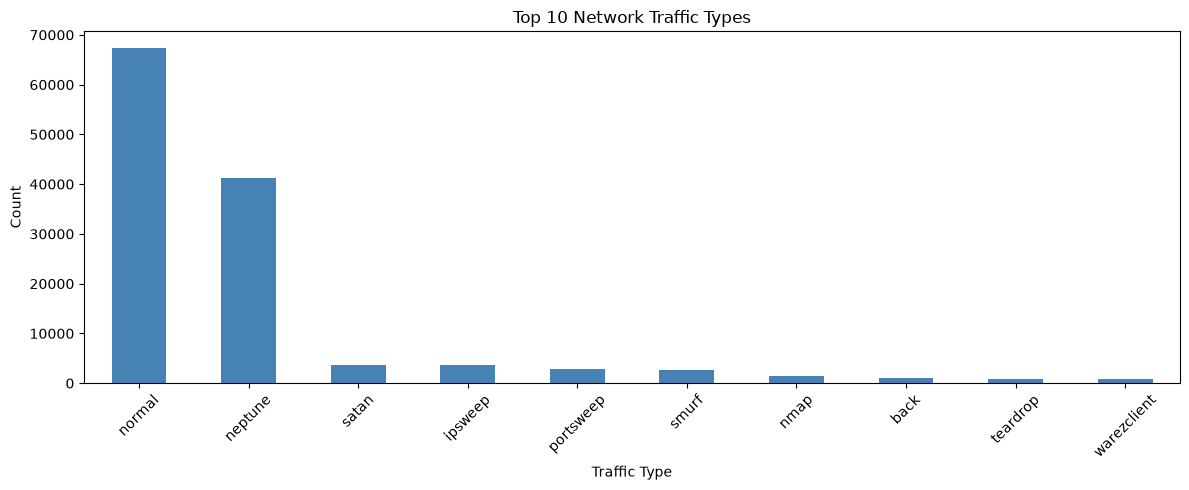

In [6]:
top_labels = df["label"].value_counts().head(10)

plt.figure(figsize=(12, 5))
top_labels.plot(kind="bar", color="steelblue")
plt.title("Top 10 Network Traffic Types")
plt.xlabel("Traffic Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

  traffic_type  count
0       Attack  58630
1       Normal  67343


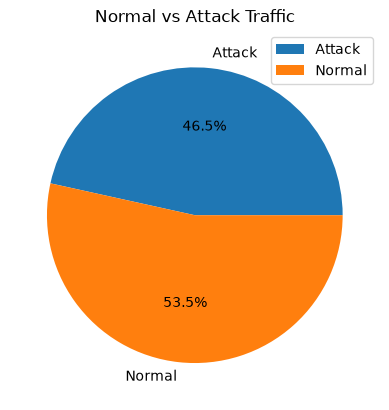

In [9]:
import sqlite3

conn = sqlite3.connect("network.db")
df.to_sql("traffic", conn, if_exists="replace", index=False)
result = pd.read_sql_query("""
    SELECT 
        CASE WHEN label = 'normal' THEN 'Normal' ELSE 'Attack' END AS traffic_type,
        COUNT(*) as count
    FROM traffic
    GROUP BY traffic_type
""", conn)
print(result)
result.plot(kind="pie", y="count", labels=result["traffic_type"], autopct="%1.1f%%")
plt.title("Normal vs Attack Traffic")
plt.ylabel("")
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder
df_ml = df.copy()
for col in ["protocol_type", "service", "flag"]:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
df_ml["is_attack"] = (df_ml["label"] != "normal").astype(int)
X = df_ml.drop(["label", "difficulty", "is_attack"], axis=1)
y = df_ml["is_attack"]
print("Features shape:", X.shape)
print("Attack distribution:\n", y.value_counts())

Features shape: (125973, 41)
Attack distribution:
 is_attack
0    67343
1    58630
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\n", classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))

Accuracy: 99.86 %

               precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13422
      Attack       1.00      1.00      1.00     11773

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



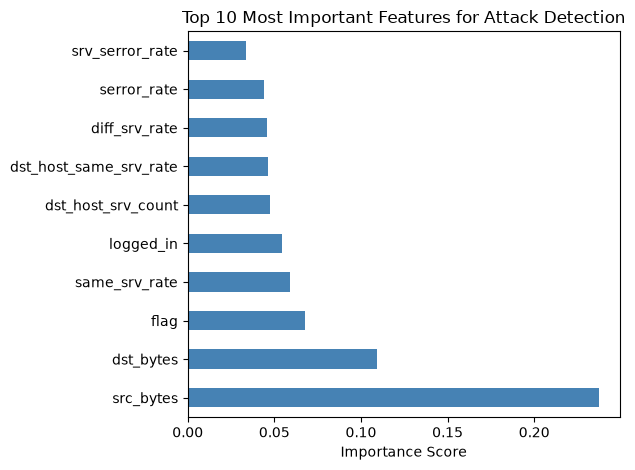

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = feature_importance.sort_values(ascending=False).head(10)
top_features.plot(kind="barh", color="steelblue")
plt.title("Top 10 Most Important Features for Attack Detection")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

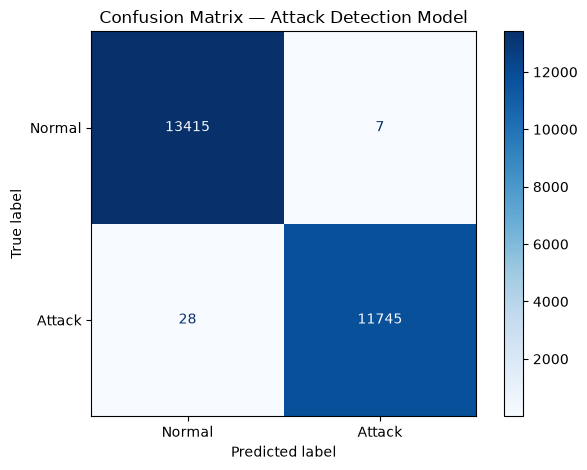

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Attack Detection Model")
plt.tight_layout()
plt.show()